## Importação das bibliotecas

In [280]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Carregamento dos dados

In [281]:
data_excel = pd.read_excel("ifood_mock_dataset.xlsx", sheet_name=None)
print(data_excel.keys())
print('--------------------------------\n')

df_customers = data_excel["customers"]
df_customers.info()

dict_keys(['customers', 'merchants', 'riders', 'orders', 'reviews'])
--------------------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customer_id       500 non-null    int64         
 1   nome_completo     500 non-null    object        
 2   data_nascimento   481 non-null    datetime64[ns]
 3   cpf               500 non-null    object        
 4   cidade            500 non-null    object        
 5   estado            500 non-null    object        
 6   data_cadastro     500 non-null    datetime64[ns]
 7   opt_in_marketing  500 non-null    bool          
dtypes: bool(1), datetime64[ns](2), int64(1), object(4)
memory usage: 28.0+ KB


### Tabela Customers

In [282]:
df_customers.head(5)

,customer_id,nome_completo,data_nascimento,cpf,cidade,estado,data_cadastro,opt_in_marketing
0,1,Cliente_1,1994-12-30,868.981.888-23,BH,MG,2023-10-28,True
1,2,Cliente_2,1991-02-14,897.535.324-32,Belo Horizonte,MG,2022-02-02,False
2,3,Cliente_3,1900-01-01,923.812.630-69,BH,MG,2022-04-06,False
3,4,Cliente_4,2000-12-26,151.670.355-25,RJ,RJ,2023-02-20,True
4,5,Cliente_5,2000-01-06,567.236.920-69,Sao Paulo,SP,2023-01-24,False


In [283]:
# Unificar o formato do CPF, removendo caracteres não numéricos
df_customers["cpf"] = df_customers["cpf"].astype(str).str.replace(r'\D', '', regex=True)

# Verificar se há CPF com tamanho inválido (diferente de 11 dígitos)
invalid_cpf = df_customers["cpf"].str.len() != 11
print(f"Quantidade de CPFs inválidos: {invalid_cpf.sum()}")

Quantidade de CPFs inválidos: 0


In [284]:
# Identificar se há duplicatas no CPF
print(df_customers["cpf"].duplicated().any()) # True -> há duplicatas
# Não pode haver duplicatas no CPF, pois é um identificador único de cada cliente. Portanto, duplicatas geralmente indicam erros de cadastro, tentativas de fraude ou atualizações de sistemas.

print(f"Quantidade de CPFs duplicados: {df_customers['cpf'].duplicated().sum()}")
print('--------------------------------\n')
# Dados "estranhos" são ouro para a equipe de Prevenção à Fraude. Em vez de apagar ou mascarar o dado, nós o mantemos, mas criamos uma nova coluna (uma flag) para sinalizar o problema.

df_customers["flag_cpf_duplicado"] = df_customers["cpf"].duplicated(keep=False)

# df_customers[df_customers["cpf"].duplicated(keep=False)]
df_customers["flag_cpf_duplicado"].head()

True
Quantidade de CPFs duplicados: 5
--------------------------------



0     True
1    False
2    False
3    False
4    False
Name: flag_cpf_duplicado, dtype: bool

Foram identificadas 5 duplicatas de CPF. As linhas em que constam essas duplicatas possuem os demais valores distintos. Como se trata de um dado único para cada cliente, essas duplicatas podem indicar tentativas de fraude ou erro de sistema. Apesar de 5 ocorrências representar apenas 1% da base de dados, não é recomendada a sua exclusão já que pode interferir na análise das outras tabelas (como a de pedidos, por exemplo). E como existe a possibilidade de ser tentativa de fraude, optamos por criar uma nova coluna `flag_cpf_duplicado` para que o time de Prevenção à Fraude possa investigar o problema.

Dessa análise dos CPFs duplicados foi possível perceber a existência de clientes cadastrados com menos de 18 anos. Entretanto, é permitido o cadastro a partir dos 16 anos de idade, conforme Termos de Uso do aplicativo. Ainda assim há clientes com idade menor que essa. Outro problema encontrado foram clientes nascidos em 01/01/1900, com mais de 100 anos. Esses dados precisam ser tratados.

In [285]:
# calcula os anos e compara se o aniversário já passou no ano do cadastro
years = df_customers["data_cadastro"].dt.year - df_customers["data_nascimento"].dt.year
had_birthday = (
    df_customers["data_cadastro"].dt.strftime("%m%d")
    >= df_customers["data_nascimento"].dt.strftime("%m%d")
)

df_customers["idade_cadastro"] = years - (~had_birthday).astype(int)

df_customers["idade_cadastro"].describe().round(2)

count    481.00
mean      21.24
std       16.70
min        5.00
25%       13.00
50%       20.00
75%       26.00
max      123.00
Name: idade_cadastro, dtype: float64

In [286]:
# Pelo método describe(), podemos ver que a idade mínima é 5 e a máxima é 123. É necessário ter ao menos 16 anos para se cadastrar.
age_condition = df_customers.loc[(df_customers["idade_cadastro"] > 100) | (df_customers["idade_cadastro"] < 16), ["nome_completo", "data_nascimento", "idade_cadastro"]]
age_condition = age_condition.sort_values(by="idade_cadastro", ascending=False)
print(f"Número de ocorrências: {len(age_condition)}")
age_condition.head(5)


Número de ocorrências: 180


,nome_completo,data_nascimento,idade_cadastro
196,Cliente_197,1900-01-01,123.0
75,Cliente_76,1900-01-01,123.0
335,Cliente_336,1900-01-01,123.0
2,Cliente_3,1900-01-01,122.0
367,Cliente_368,1900-01-01,122.0


In [287]:
# Os cadastros com mais de 100 possuem data de nascimento em 01/01/1900, o que provavelmente indica erro do usuário no momento do cadastro. Como são 180 datas de nascimento inválidas em uma base de 500, manteremos as linhas e alteraremos essas datas para um valor nulo, a fim de que não interfiram nas próximas análises.
df_customers.loc[age_condition.index, "data_nascimento"] = pd.NaT
df_customers.loc[age_condition.index, "idade_cadastro"] = np.nan
df_customers.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   customer_id         500 non-null    int64         
 1   nome_completo       500 non-null    object        
 2   data_nascimento     301 non-null    datetime64[ns]
 3   cpf                 500 non-null    object        
 4   cidade              500 non-null    object        
 5   estado              500 non-null    object        
 6   data_cadastro       500 non-null    datetime64[ns]
 7   opt_in_marketing    500 non-null    bool          
 8   flag_cpf_duplicado  500 non-null    bool          
 9   idade_cadastro      301 non-null    float64       
dtypes: bool(2), datetime64[ns](2), float64(1), int64(1), object(4)
memory usage: 32.4+ KB


In [288]:
df_customers.loc[age_condition.index, "data_nascimento"] = pd.NaT

df_customers.loc[age_condition.index, ["nome_completo", "data_nascimento"]].head()

,nome_completo,data_nascimento
196,Cliente_197,NaT
75,Cliente_76,NaT
335,Cliente_336,NaT
2,Cliente_3,NaT
367,Cliente_368,NaT


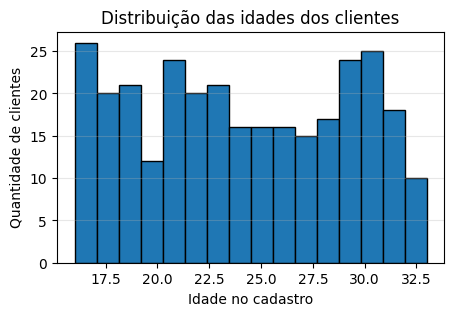

In [289]:
df_customers["idade_cadastro"].dropna().plot(
  kind="hist",
  bins=16,
  figsize=(5, 3),
  edgecolor="black"
)

plt.title("Distribuição das idades dos clientes")
plt.xlabel("Idade no cadastro")
plt.ylabel("Quantidade de clientes")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [290]:
# Tratamento da coluna cidade
df_customers["cidade"].unique()

array(['BH', 'Belo Horizonte', 'RJ', 'Sao Paulo', 'SP', 'São Paulo',
       'Rio de Janeiro', 'S. Paulo'], dtype=object)

In [291]:
# Dicionário de correção
mapeamento_cidades = {
    'BH': 'Belo Horizonte',
    'RJ': 'Rio de Janeiro',
    'Sao Paulo': 'São Paulo',
    'SP': 'São Paulo',
    'S. Paulo': 'São Paulo'
}

# Aplicação do .replace() na coluna
df_customers["cidade"] = df_customers["cidade"].replace(mapeamento_cidades)

print(df_customers["cidade"].unique())

['Belo Horizonte' 'Rio de Janeiro' 'São Paulo']


In [292]:
df_customers["estado"].unique()

array(['MG', 'RJ', 'SP'], dtype=object)

In [293]:
df_customers["data_cadastro"].describe()

count                              500
mean     2022-12-29 03:12:57.599999744
min                2022-01-05 00:00:00
25%                2022-07-09 12:00:00
50%                2023-01-04 00:00:00
75%                2023-06-19 18:00:00
max                2023-12-02 00:00:00
Name: data_cadastro, dtype: object

In [294]:
# Cria a coluna de Cohort (Ano-Mês)
# O formato '%Y-%m' extrai o ano com 4 dígitos e o mês com 2 dígitos (ex: 2023-08)
df_customers['cohort_cadastro'] = df_customers['data_cadastro'].dt.strftime('%Y-%m')

# Visualizando o resultado
print(df_customers[['data_cadastro', 'cohort_cadastro']].head())

  data_cadastro cohort_cadastro
0    2023-10-28         2023-10
1    2022-02-02         2022-02
2    2022-04-06         2022-04
3    2023-02-20         2023-02
4    2023-01-24         2023-01


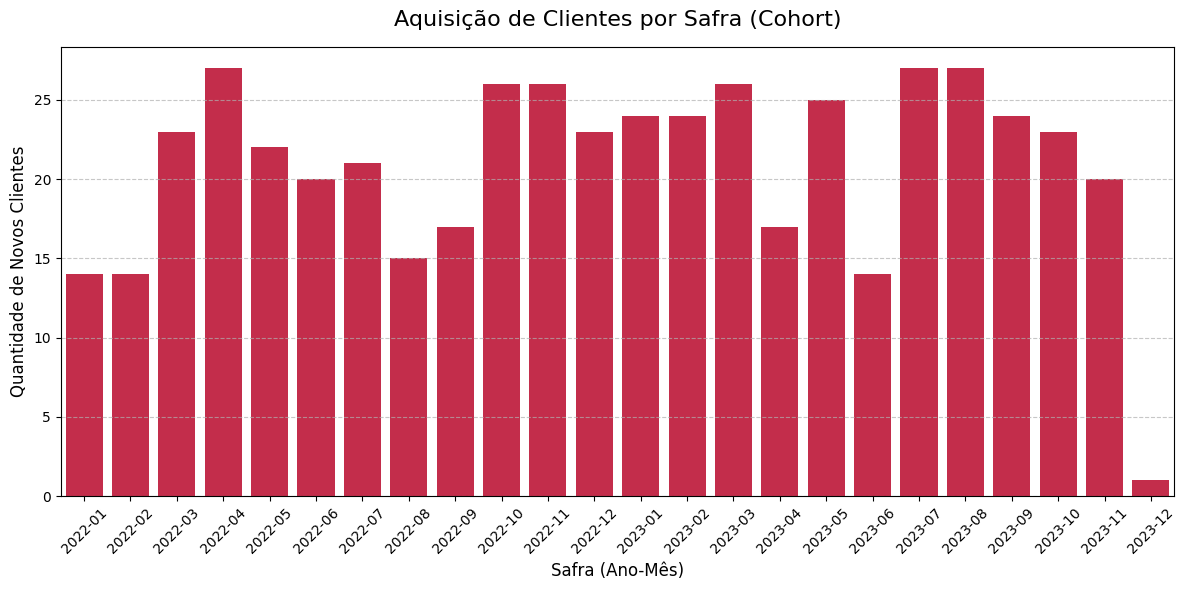

In [295]:
plt.figure(figsize=(12, 6))

cohort_labels = df_customers['cohort_cadastro'].sort_values()

sns.countplot(x=cohort_labels, color="crimson")
plt.title('Aquisição de Clientes por Safra (Cohort)', fontsize=16, pad=15)
plt.xlabel('Safra (Ano-Mês)', fontsize=12)
plt.ylabel('Quantidade de Novos Clientes', fontsize=12)
# Rotacionar os rótulos do eixo X em 45 graus para não ficarem sobrepostos
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()